# MLB 2026 Playoff Prediction — Analysis

This notebook walks through the modeling results: data overview, Elo power ratings, win-probability model comparison (Elo baseline vs logistic regression vs XGBoost), calibration, and the simulated 2026 playoff odds.

Run `python run_pipeline.py` first — this notebook reads its outputs.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'outputs'

games = pd.read_csv(ROOT / 'data/raw/games.csv', parse_dates=['date'])
odds = pd.read_csv(OUT / 'playoff_odds_2026.csv')
elo = pd.read_csv(OUT / 'elo_current.csv')
metrics = json.loads((OUT / 'metrics.json').read_text())
calibration = pd.read_csv(OUT / 'calibration.csv')
print(f'{len(games):,} completed games, {games.season.min()}-{games.season.max()}')

26,194 completed games, 2015-2026


## 1. Data overview

Completed regular-season games per season, and the league-wide home win rate — the base rate any model has to beat.

In [2]:
by_season = games.groupby('season').agg(games_played=('game_id', 'count'),
                                        home_win_rate=('home_win', 'mean')).round(3)
by_season

,games_played,home_win_rate
season,,
2015,2429,0.542
2016,2427,0.530
2017,2430,0.540
2018,2431,0.528
2019,2429,0.529
2020,898,0.550
2021,2429,0.538
2022,2430,0.533
2023,2430,0.521


## 2. Current Elo power ratings (top/bottom 10)

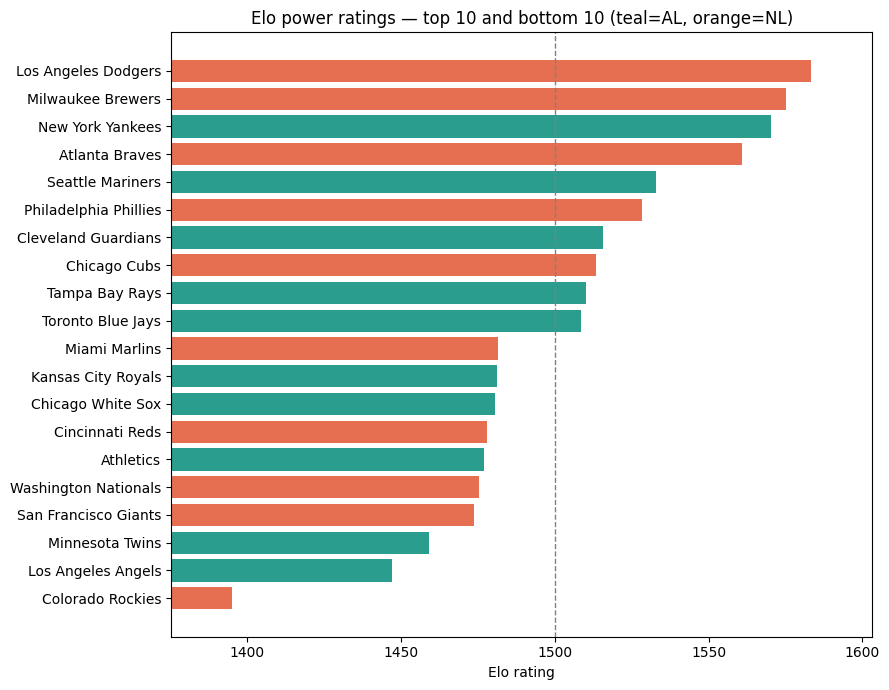

In [3]:
ranked = elo.sort_values('elo', ascending=False)
show = pd.concat([ranked.head(10), ranked.tail(10)])
colors = ['#2a9d8f' if l == 'American League' else '#e76f51' for l in show.league]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(show.team_name[::-1], show.elo[::-1], color=colors[::-1])
ax.axvline(1500, color='gray', ls='--', lw=1)
ax.set_xlabel('Elo rating')
ax.set_title('Elo power ratings — top 10 and bottom 10 (teal=AL, orange=NL)')
ax.set_xlim(show.elo.min() - 20, show.elo.max() + 20)
plt.tight_layout(); plt.show()

## 3. Model comparison

Held-out test set = 2025 + played 2026 games. Log loss and Brier score are the headline metrics — for win probabilities, calibration matters more than accuracy.

In [4]:
rows = [{'model': k, **v} for k, v in metrics.items() if isinstance(v, dict)]
pd.DataFrame(rows).set_index('model').round(4)

,log_loss,brier,auc,accuracy,n_games
model,,,,,
elo_baseline,0.6817,0.2444,0.5693,0.5638,3432
logistic_regression,0.6813,0.2442,0.5696,0.5621,3432
xgboost,0.6843,0.2457,0.5592,0.5557,3432


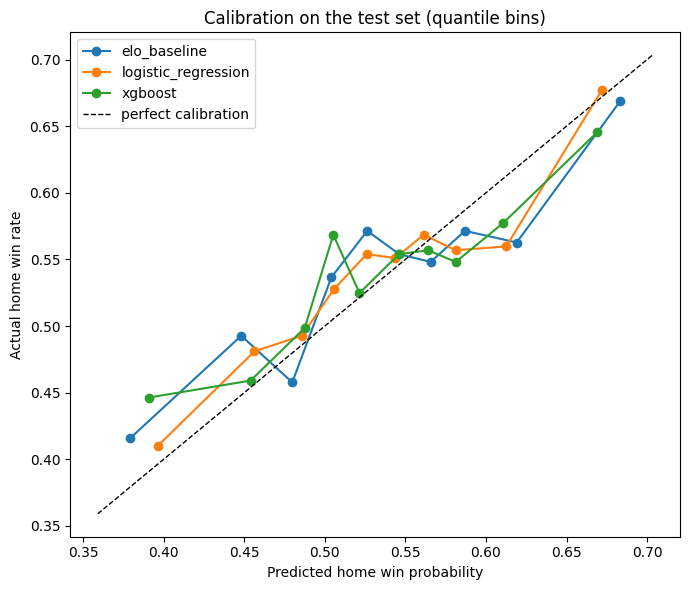

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, grp in calibration.groupby('model'):
    ax.plot(grp.mean_predicted, grp.fraction_won, marker='o', label=name)
lims = [calibration.mean_predicted.min() - .02, calibration.mean_predicted.max() + .02]
ax.plot(lims, lims, 'k--', lw=1, label='perfect calibration')
ax.set_xlabel('Predicted home win probability')
ax.set_ylabel('Actual home win rate')
ax.set_title('Calibration on the test set (quantile bins)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Simulated 2026 playoff odds

10,000 Monte Carlo simulations of the remaining schedule + full postseason bracket.

In [6]:
cols = ['team_name', 'league', 'division', 'current_wins', 'proj_wins',
        'make_playoffs', 'win_division', 'win_pennant', 'win_world_series']
styled = odds[cols].sort_values('win_world_series', ascending=False).head(15).copy()
styled['proj_wins'] = styled['proj_wins'].round(1)
for c in ['make_playoffs', 'win_division', 'win_pennant', 'win_world_series']:
    styled[c] = (styled[c] * 100).round(1).astype(str) + '%'
styled.reset_index(drop=True)

,team_name,league,division,current_wins,proj_wins,make_playoffs,win_division,win_pennant,win_world_series
0,Los Angeles Dodgers,National League,National League West,43,102.2,100.0%,99.7%,35.3%,22.4%
1,New York Yankees,American League,American League East,40,98.2,100.0%,90.3%,43.6%,22.3%
2,Milwaukee Brewers,National League,National League Central,41,99.6,99.9%,97.5%,27.5%,16.4%
3,Atlanta Braves,National League,National League East,45,100.6,99.9%,97.2%,22.9%,13.1%
4,Seattle Mariners,American League,American League West,36,88.1,92.4%,75.4%,19.2%,7.4%
5,Cleveland Guardians,American League,American League Central,37,87.7,92.3%,81.8%,13.2%,4.5%
6,Tampa Bay Rays,American League,American League East,39,88.9,93.7%,9.1%,8.7%,2.9%
7,Philadelphia Phillies,National League,National League East,36,86.7,74.0%,2.7%,5.3%,2.4%
8,Texas Rangers,American League,American League West,32,82.2,58.1%,17.8%,5.6%,2.0%
9,Toronto Blue Jays,American League,American League East,33,80.4,42.0%,0.4%,3.2%,1.1%


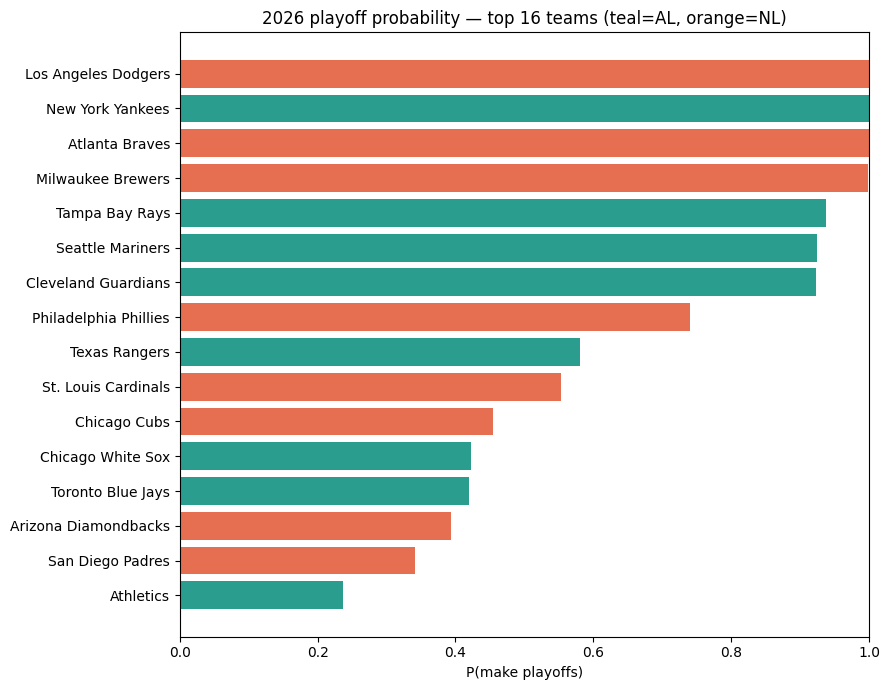

In [7]:
top = odds.sort_values('make_playoffs', ascending=False).head(16)
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2a9d8f' if l == 'American League' else '#e76f51' for l in top.league]
ax.barh(top.team_name[::-1], top.make_playoffs[::-1], color=colors[::-1])
ax.set_xlabel('P(make playoffs)')
ax.set_xlim(0, 1)
ax.set_title('2026 playoff probability — top 16 teams (teal=AL, orange=NL)')
plt.tight_layout(); plt.show()

## 5. Takeaways

- Baseball single games are near coin flips: a well-calibrated ~0.58 ceiling on win probability is expected, so **log loss vs the Elo baseline** is the fair test of whether the ML features add signal.
- The Monte Carlo layer converts game-level edges into season-level statements (playoff %, World Series %) — small per-game differences compound over ~80 remaining games.
- Next iteration: add probable starting pitchers (available from the same API) and re-run the comparison.